# Wind Calibration Tutorial

This notebook shows a practical end-to-end workflow for running wind calibration locally with `WindCalibrator` and checking the generated output files.


## 1) Environment and Setup 

Before running the notebook:

- Use Python 3.12.
- Install project dependencies (including notebook extras): `uv sync --group notebook`. This should be executed in the terminal window.
- Ensure NetCDF support is available (`xarray` + `netCDF4`) because ERA5 loading and ingestion depends on it.

> If `uv` is not available in your environment, install dependencies with your standard Python package workflow.

In [7]:
from pathlib import Path

import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from weather.calibration.wind.wind_calibrator import WindCalibrator

## 2) Required Input Folder Structure and Files

`WindCalibrator` expects a base `data_path` with these subfolders:

- `plant/plant_data.csv`
- `generation/generation_data.parquet`
- `era5/*.nc` (one or more ERA5 NetCDF files)

In [2]:
DATA_PATH = Path('data')
OUTPUT_PATH = Path('outputs/wind_calibration')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print('Data path:', DATA_PATH.resolve())
print('Output path:', OUTPUT_PATH.resolve())

Data path: /Users/matthewcampbell/Weather Repo/weather/data
Output path: /Users/matthewcampbell/Weather Repo/weather/outputs/wind_calibration


## 3) Downloading the Calibration Inputs

The calibration workflow needs three input datasets:

1. **Plant data**: Plant metadata and CfD/BMU mapping. Ingested through the `CfDDataDownloader` via an API from the Low Carbon Contracts Company (LCCC)
2. **Generation data**: Historical generation for those plants. Ingested through the `GenerationDataDownloader` via an API from Elexon BMRS.
3. **ERA5 weather data**: Hourly reanalysis weather data in NetCDF format. Ingested through the `ERA5DataDownloader` from the Copernicus Climate Data Store via `cdsapi`

This repository provides a `DownloadManager` that downloads and saves these inputs into the expected folder structure under `data/`:

- `data/plant/`
- `data/generation/`
- `data/era5/`

> Note: ERA5 downloads require a valid `CDS_API_KEY`. This can be saved in .env-example.

In [3]:
from weather.core.data_downloader import DownloadManager

In [5]:
dm = DownloadManager()

# Download everything needed for calibration
dm.download_all()

### Optional: download data step-by-step instead of all at once

In [6]:
dm = DownloadManager()

# 1. Download plant metadata / CfD mapping
dm.download_cfd()

# 2. Download generation data for those plants in CfD metadata
dm.download_generation_data()

# 3. Download ERA5 weather data
dm.download_era5()

[INFO] - Loading CfD plant data with BMU mapping... - [data_downloader] - 2026-05-19 13:49:09
[INFO] - Found 127 unique BMU IDs. - [data_downloader] - 2026-05-19 13:49:09


### Pre-Check: verify that all the data has been downloaded



In [18]:
required_paths = [
    DATA_PATH / 'plant',
    DATA_PATH / 'era5',
    DATA_PATH / 'plant' / 'plant_data.csv',
    DATA_PATH / 'generation' / 'generation_data.parquet',
]

required_path_generation = [DATA_PATH / 'generation']

plant_data = pd.read_csv(DATA_PATH / 'plant' / 'plant_data.csv')
generation_data = pd.read_parquet(DATA_PATH / 'generation' / 'generation_data.parquet')

for p in required_paths:
    print(f'{p}: {"Exists" if p.exists() else "MISSING"}')

start = generation_data["time"].min()
end = generation_data["time"].max()

for path in required_path_generation:
    status = "Exists" if path.exists() else "MISSING"
    print(f"{path}: {status} | range: {start} → {end}")

era5_files = sorted((DATA_PATH / 'era5').glob('*.nc'))
print(f'ERA5 files found: {len(era5_files)}')
for path in era5_files[:10]:
    print(f'  - {path.name}')
if len(era5_files) > 10:
    print(f'  ... and {len(era5_files) - 10} more')

data/plant: Exists
data/era5: Exists
data/plant/plant_data.csv: Exists
data/generation/generation_data.parquet: Exists
data/generation: Exists | range: 2023-01-01 00:00:00+00:00 → 2023-01-31 23:00:00+00:00
ERA5 files found: 555
  - ERA5_wind_1980_01.nc
  - ERA5_wind_1980_02.nc
  - ERA5_wind_1980_03.nc
  - ERA5_wind_1980_04.nc
  - ERA5_wind_1980_05.nc
  - ERA5_wind_1980_06.nc
  - ERA5_wind_1980_07.nc
  - ERA5_wind_1980_08.nc
  - ERA5_wind_1980_09.nc
  - ERA5_wind_1980_10.nc
  ... and 545 more


### Optional pre-check: verify ERA5 NetCDF can be opened

If this fails, calibration will fail during ERA5 loading.

In [8]:
if era5_files:
    test_file = era5_files[0]
    print('Testing ERA5 file:', test_file)
    try:
        ds = xr.open_dataset(test_file, engine='netcdf4')
        print('Opened successfully. Variables:', list(ds.data_vars)[:10])
        ds.close()
    except Exception as exc:
        print('Failed to open ERA5 file with netcdf4:', exc)
else:
    print('No ERA5 files found. Add .nc files under data/era5/.')

Testing ERA5 file: data/era5/ERA5_wind_1980_01.nc
Failed to open ERA5 file with netcdf4: unrecognized engine netcdf4 must be one of: ['scipy', 'store']


## 4) Import and Configure `WindCalibrator`

The key arguments are:

- `data_path`: base folder containing `plant/`, `generation/`, `era5/`
- `output_path`: where calibration outputs are written
- `visual_output`: save power curve PNG plots when `True`
- `stream_npy_output`: also save `Wind Streams.npy` when `True`

In [8]:
wc = WindCalibrator(
    data_path=str(DATA_PATH),
    output_path=OUTPUT_PATH,
    visual_output=True,
    stream_npy_output=True,
)

[INFO] - Plant data loaded: 144 plants, 22609.6 MW total capacity - [data_loader] - 2026-05-19 14:15:51
[INFO] - Generation data loaded: 26040 records, 35 plants - [data_loader] - 2026-05-19 14:15:51
[INFO] - ERA5 data loaded: 555 files, 405408 time periods - [data_loader] - 2026-05-19 14:16:54


## 5) Run Calibration

This executes the full workflow and writes outputs to `output_path`. Add more explanation on what calibration is doing, logistic functions

In [9]:
wc.calibrate()

[INFO] - Starting calibration process... - [wind_calibrator] - 2026-05-19 14:16:58
[INFO] - Extracting resource data for plants... - [wind_calibrator] - 2026-05-19 14:17:19
[INFO] - Written plant-wise resource dataset to outputs/wind_calibration/Wind Speeds.csv - [wind_calibrator] - 2026-05-19 14:18:16
[INFO] - Clculating historical load factors... - [wind_calibrator] - 2026-05-19 14:18:17
[INFO] - Fitting probability distribution to historical load factors... - [wind_calibrator] - 2026-05-19 14:18:18
[INFO] - Written historical load factor parameters to outputs/wind_calibration/Weibull Params.csv - [wind_calibrator] - 2026-05-19 14:18:19
[INFO] - Estimating long-term load factors for plants... - [wind_calibrator] - 2026-05-19 14:18:19
[INFO] - AAA-ACH-183 - [wind_calibrator] - 2026-05-19 14:18:19
[INFO] - AAA-BAD-185 - [wind_calibrator] - 2026-05-19 14:18:19
[INFO] - AAA-BAN-189 - [wind_calibrator] - 2026-05-19 14:18:19
[INFO] - AAA-BAN-192 - [wind_calibrator] - 2026-05-19 14:18:19
[I

## 6) Inspect Generated Outputs

After calibration completes, this notebook should produce:

- `Calibration Summary.csv`
- `Weibull Params.csv`
- `Wind Speeds.csv`
- `Wind Streams.parquet`
- `PowerCurveFit_*.png` (if `visual_output=True`)
- `Wind Streams.npy` (if `stream_npy_output=True`)

In [12]:
# list of the generated outputs
sorted([p.name for p in OUTPUT_PATH.glob('*')])

['Calibration Summary.csv',
 'PowerCurveFit_AAA-ACH-183.png',
 'PowerCurveFit_AAA-BAD-185.png',
 'PowerCurveFit_AAA-BAN-189.png',
 'PowerCurveFit_AAA-BAN-192.png',
 'PowerCurveFit_AAA-COI-196.png',
 'PowerCurveFit_AAA-DOR-182.png',
 'PowerCurveFit_AAA-NAN-184.png',
 'PowerCurveFit_AAA-PNE-187.png',
 'PowerCurveFit_AAA-SOL-181.png',
 'PowerCurveFit_AR2-HRN-106.png',
 'PowerCurveFit_AR2-HRN-206.png',
 'PowerCurveFit_AR2-HRN-306.png',
 'PowerCurveFit_AR2-MRY-107.png',
 'PowerCurveFit_AR2-MRY-207.png',
 'PowerCurveFit_AR2-MRY-307.png',
 'PowerCurveFit_AR2-TKN-103.png',
 'PowerCurveFit_AR2-TKN-203.png',
 'PowerCurveFit_AR2-TKN-303.png',
 'PowerCurveFit_CAA-EAS-166.png',
 'PowerCurveFit_CAA-EAS-167.png',
 'PowerCurveFit_CAA-EAS-168.png',
 'PowerCurveFit_INV-BEA-001.png',
 'PowerCurveFit_INV-BEA-002.png',
 'PowerCurveFit_INV-BUR-001.png',
 'PowerCurveFit_INV-DUD-001.png',
 'PowerCurveFit_INV-DUD-002.png',
 'PowerCurveFit_INV-DUD-003.png',
 'PowerCurveFit_INV-HOR-001.png',
 'PowerCurveFit_INV-

### Output: 1 - Calibration Summary

Calibration summary CSV containing 5-parameters function parameters and generator estimated load factors

In [13]:
summary = pd.read_csv(OUTPUT_PATH / 'Calibration Summary.csv')

display(summary)

,PLANT ID,a,b,c,d,g,Estimated Load Factor
0,AAA-ACH-183,0.0,3.595720,49.999912,1.0,244.088350,0.5202
1,AAA-BAD-185,0.0,18.389694,3.991162,1.0,0.028210,0.3467
2,AAA-BAN-189,0.0,9.447265,4.224791,1.0,0.100526,0.4142
3,AAA-BAN-192,0.0,9.013572,5.036743,1.0,0.118988,0.3844
4,AAA-COI-196,0.0,2.944727,50.000000,1.0,132.017650,0.4047
5,AAA-DOR-182,0.0,6.769478,0.317123,1.0,0.021133,0.3662
6,AAA-NAN-184,0.0,3.454016,5.107421,1.0,0.761216,0.6270
7,AAA-PNE-187,0.0,6.420878,6.604513,1.0,0.214016,0.3786
8,AAA-SOL-181,0.0,3.381137,11.106168,1.0,1.634766,0.3847
9,AR2-HRN-106,0.0,7.259315,7.818244,1.0,0.385119,0.5874


### Output: 2 - Weibull Parameters

Weilbull Parameters CSV displaying each wind farms parameters k and λ of the Weibull distribution of the wind speed frequency.

In [14]:
weibull = pd.read_csv(OUTPUT_PATH / 'Weibull Params.csv')

display(weibull)

,plant_id,wind_speed_mean,wind_speed_stdev,k,lambda
0,AR2-MRY-107,11.534140,3.727305,3.352759,12.832010
1,AAA-PNE-187,9.774436,4.057542,2.601471,11.009313
2,AAA-COI-196,7.452876,3.093030,2.585057,8.399076
3,AAA-BAN-192,8.616841,3.279574,2.833196,9.666354
4,INV-HOR-001,12.243521,5.228450,2.531647,13.765421
5,AR2-HRN-206,12.240538,5.014716,2.678397,13.762076
6,AR2-HRN-106,12.242567,5.123046,2.605867,13.767497
7,INV-WAL-002,11.764718,4.966975,2.550471,13.250903
8,INV-DUD-002,11.688482,5.344853,2.284897,13.105350
9,INV-BEA-001,11.074812,3.698597,3.256702,12.338167


### Output: 3 - Wind Speeds

Hourly windspeeds from 1980-01-01 to present for each plant_id

In [15]:
wind_speeds = pd.read_csv(OUTPUT_PATH / 'Wind Speeds.csv')

display(wind_speeds)

,time,plant_id,wind_speed
0,1980-01-01 00:00:00+00:00,AR3-SOW-102,12.399265
1,1980-01-01 00:00:00+00:00,AR2-MRY-107,9.994375
2,1980-01-01 00:00:00+00:00,AAA-PNE-187,3.526404
3,1980-01-01 00:00:00+00:00,AAA-COI-196,3.648929
4,1980-01-01 00:00:00+00:00,AAA-BAN-192,3.512559
...,...,...,...
19864987,2026-03-31 23:00:00+00:00,INV-BUR-001,5.795709
19864988,2026-03-31 23:00:00+00:00,INV-HOR-002,5.276858
19864989,2026-03-31 23:00:00+00:00,AR2-MRY-207,11.959147
19864990,2026-03-31 23:00:00+00:00,AR2-MRY-307,10.786353


### Output: 4 - Wind Streams

Hourly wind streams (Load Factors) from 1980-01-01 to present for each plant_id

In [16]:
wind_streams = pd.read_parquet(OUTPUT_PATH / 'Wind Streams.parquet')

display(wind_streams)

,Times,AAA-ACH-183,AAA-BAD-185,AAA-BAN-189,AAA-BAN-190,AAA-BAN-192,AAA-BRE-177,AAA-CLO-186,AAA-COI-196,AAA-COM-191,...,INV-BEA-002,INV-BUR-001,INV-DUD-001,INV-DUD-002,INV-DUD-003,INV-HOR-001,INV-HOR-002,INV-HOR-003,INV-WAL-001,INV-WAL-002
0,1980-01-01 00:00:00+00:00,0.223998,0.274140,0.000060,0.372470,0.004522,0.000526,0.000526,0.057563,0.148635,...,0.512334,0.006069,0.884706,0.902294,0.858597,0.808401,0.829007,0.811306,0.015382,0.018194
1,1980-01-01 01:00:00+00:00,0.238882,0.281810,0.000185,0.391599,0.005688,0.000599,0.000599,0.053839,0.108788,...,0.525968,0.004835,0.851458,0.870193,0.833177,0.698263,0.699639,0.716960,0.022290,0.025110
2,1980-01-01 02:00:00+00:00,0.233377,0.279031,0.000082,0.349991,0.004297,0.000458,0.000458,0.044354,0.096508,...,0.513091,0.003308,0.831558,0.850657,0.816646,0.628108,0.625618,0.647045,0.017897,0.020749
3,1980-01-01 03:00:00+00:00,0.228763,0.276650,0.000028,0.288762,0.004911,0.000203,0.000203,0.043854,0.103385,...,0.509189,0.000644,0.842470,0.861395,0.831494,0.611252,0.610268,0.633480,0.015379,0.018191
4,1980-01-01 04:00:00+00:00,0.252049,0.288207,0.000006,0.266131,0.002129,0.000145,0.000145,0.048772,0.101667,...,0.543987,0.000079,0.849846,0.868618,0.839327,0.613944,0.599007,0.631183,0.009862,0.012378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405403,2026-03-31 19:00:00+00:00,0.437689,0.355173,0.401291,0.091338,0.240780,0.012170,0.012170,0.463347,0.001711,...,0.576320,0.190432,0.000207,0.000243,0.000854,0.003989,0.001157,0.007327,0.240736,0.215453
405404,2026-03-31 20:00:00+00:00,0.430136,0.352986,0.402432,0.103349,0.248695,0.007884,0.007884,0.466437,0.001634,...,0.604888,0.135917,0.001185,0.001344,0.003164,0.021828,0.006885,0.035994,0.259867,0.232440
405405,2026-03-31 21:00:00+00:00,0.414395,0.348328,0.372283,0.080345,0.207976,0.005158,0.005158,0.446817,0.007843,...,0.607597,0.105204,0.005207,0.005730,0.006871,0.071972,0.033390,0.096316,0.300072,0.268850
405406,2026-03-31 22:00:00+00:00,0.372946,0.335331,0.385690,0.079014,0.192294,0.005683,0.005683,0.475937,0.055903,...,0.632138,0.082409,0.018103,0.019427,0.027431,0.093095,0.045418,0.126369,0.333260,0.299736


### Output: 5 - Wind Streams vs Actual Generation

Wind power curve plot outputs showing the relationship between estimated and actual load factors for a given plant_id. Estimated load factors are taken from wind_streams, while actual load factors are calculated from metered generation data as quantity / capacity. The two series are merged on cfd_id and time, filtered to a single plant, and plotted as a time series comparison.

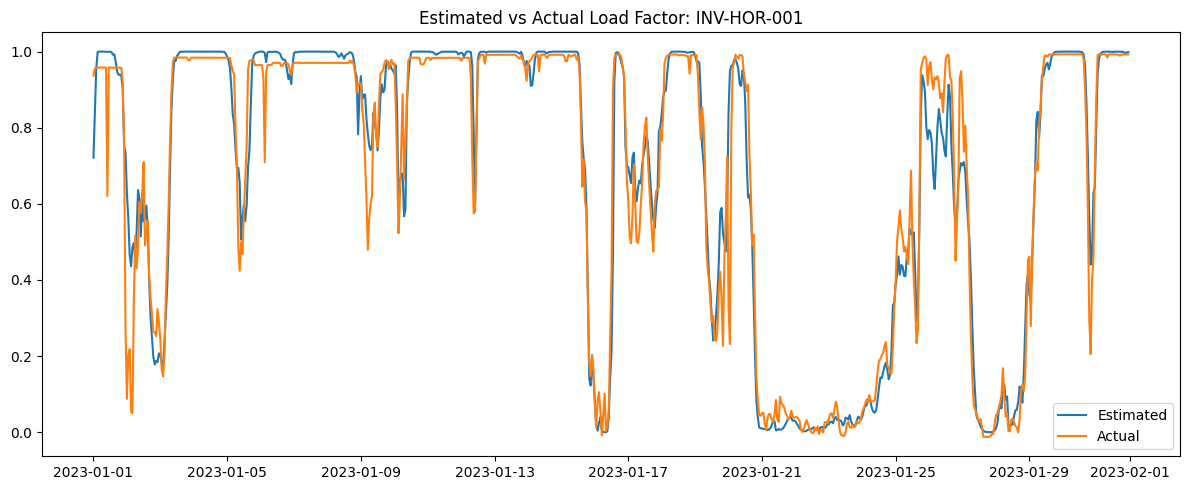

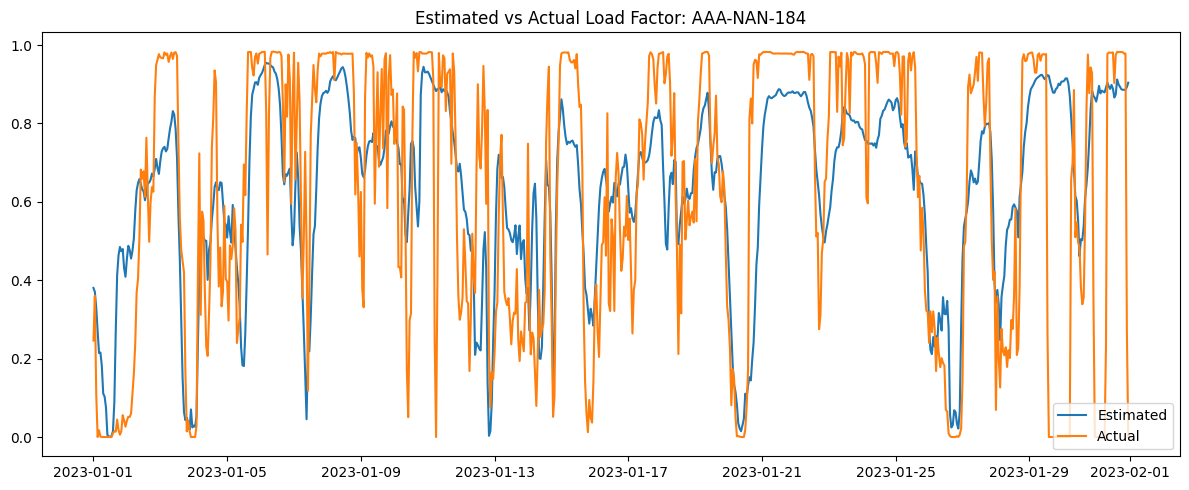

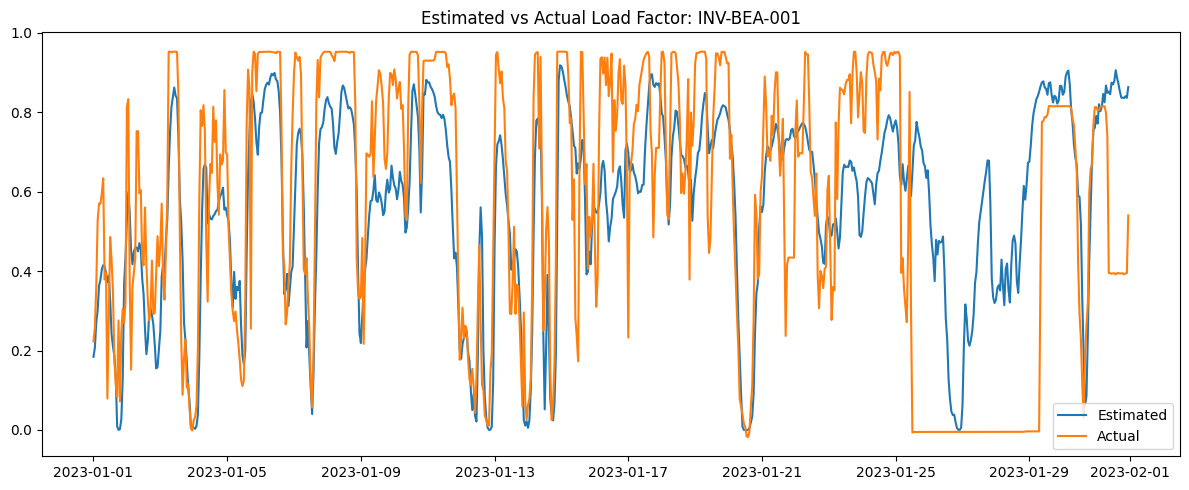

In [21]:
wind_long = wind_streams.rename(columns={"Times": "time"}).melt(
    id_vars="time",
    var_name="cfd_id",
    value_name="estimated_load_factor",
)

wind_long["time"] = pd.to_datetime(wind_long["time"], utc=True)
generation_data["time"] = pd.to_datetime(generation_data["time"], utc=True)

generation_data_capacity = generation_data.merge(
    plant_data[["cfd_id", "capacity"]],
    on="cfd_id",
    how="inner",
)

generation_data_capacity["actual_load_factor"] = (
    generation_data_capacity["quantity"] / generation_data_capacity["capacity"]
)

df = wind_long.merge(
    generation_data_capacity[["cfd_id", "time", "actual_load_factor"]],
    on=["cfd_id", "time"],
    how="inner",
)

plant_ids = ["INV-HOR-001", "AAA-NAN-184", "INV-BEA-001"]

for plant_id in plant_ids:
    plot_df = df[df["cfd_id"] == plant_id].sort_values("time")

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(plot_df["time"], plot_df["estimated_load_factor"], label="Estimated")
    ax.plot(plot_df["time"], plot_df["actual_load_factor"], label="Actual")
    ax.set_title(f"Estimated vs Actual Load Factor: {plant_id}")
    ax.legend(loc = 'lower right')
    plt.tight_layout()
    plt.show()

### Output: 6 - Power Curves

Wind power curve plot outputs showing the relationship between wind speed and load factor for each plant_id, with fitted power curves alongside average wind speed profiles.

Found 32 PNG files.



### PowerCurveFit_AAA-ACH-183.png

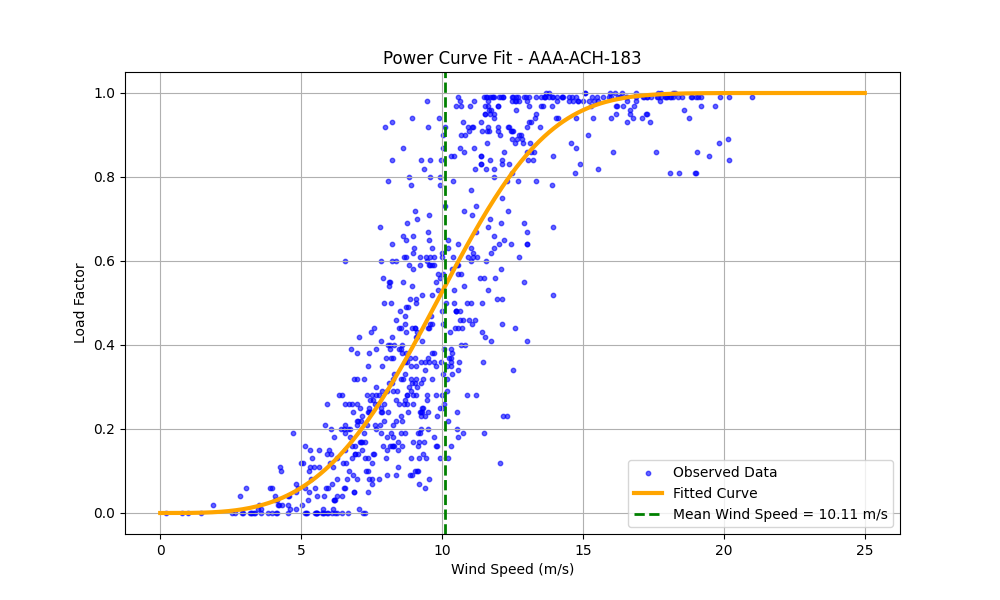

### PowerCurveFit_AAA-BAD-185.png

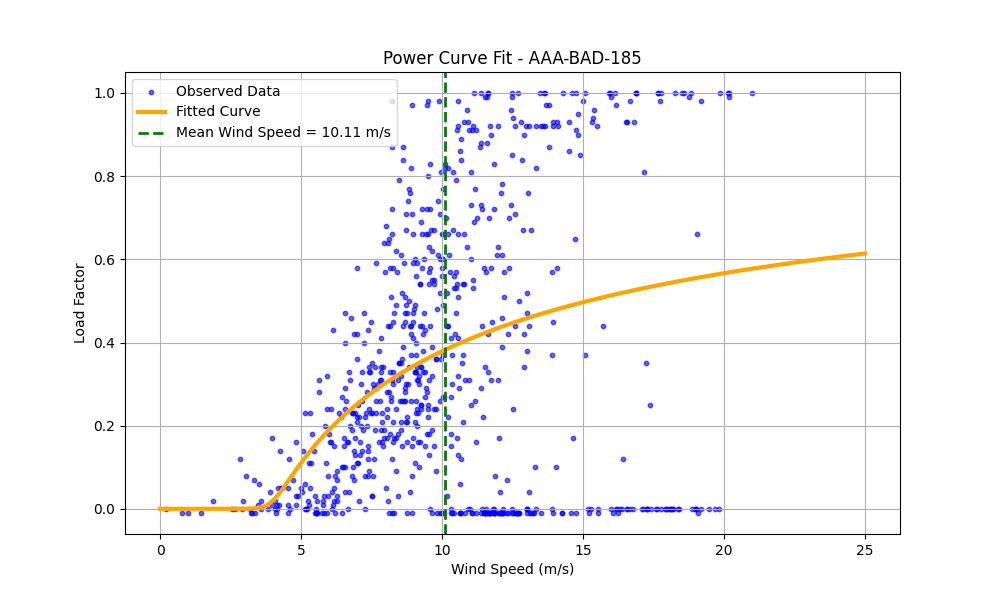

### PowerCurveFit_AAA-BAN-189.png

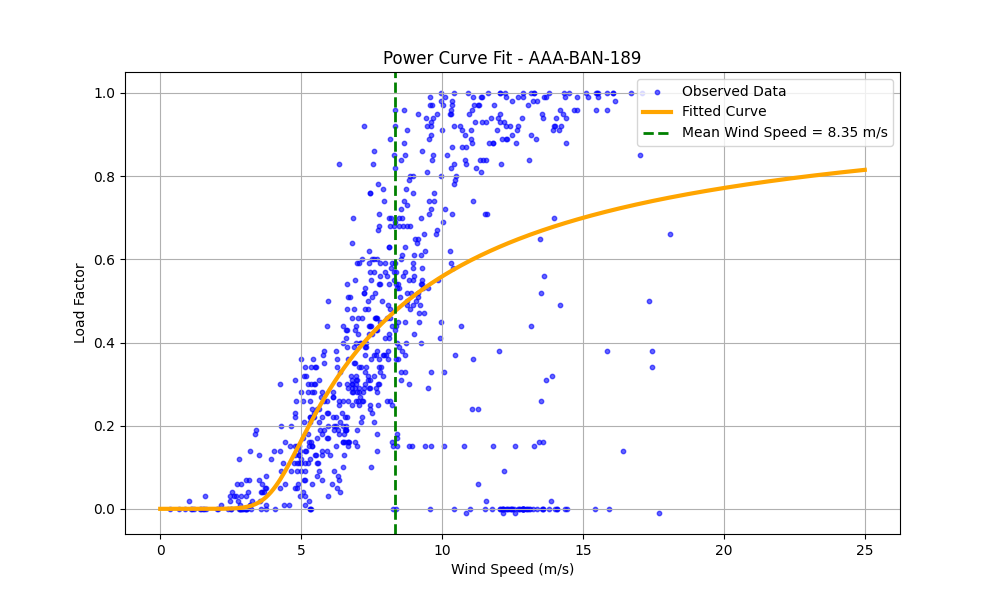

### PowerCurveFit_AAA-BAN-192.png

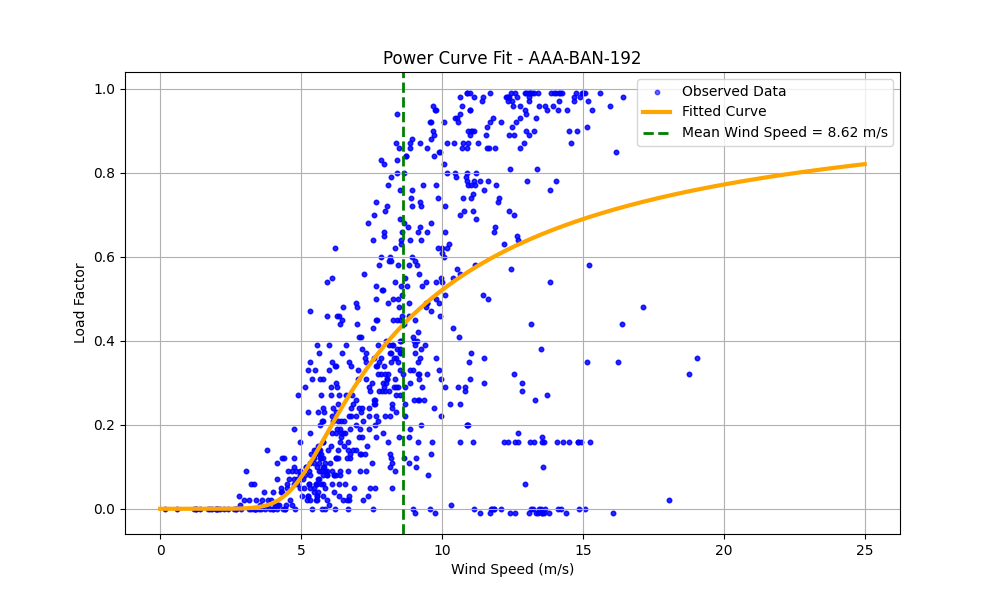

### PowerCurveFit_AAA-COI-196.png

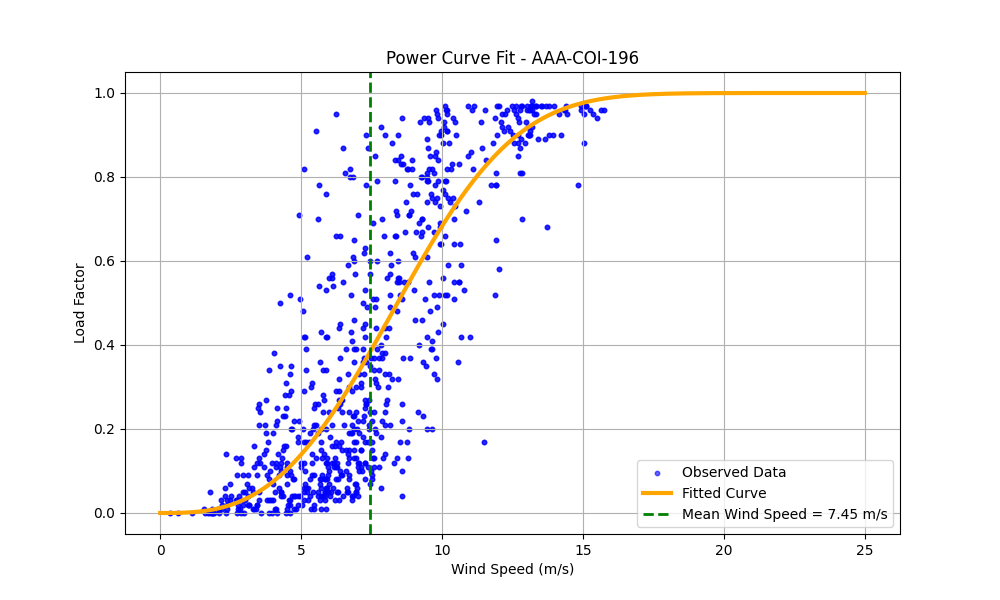

### PowerCurveFit_AAA-DOR-182.png

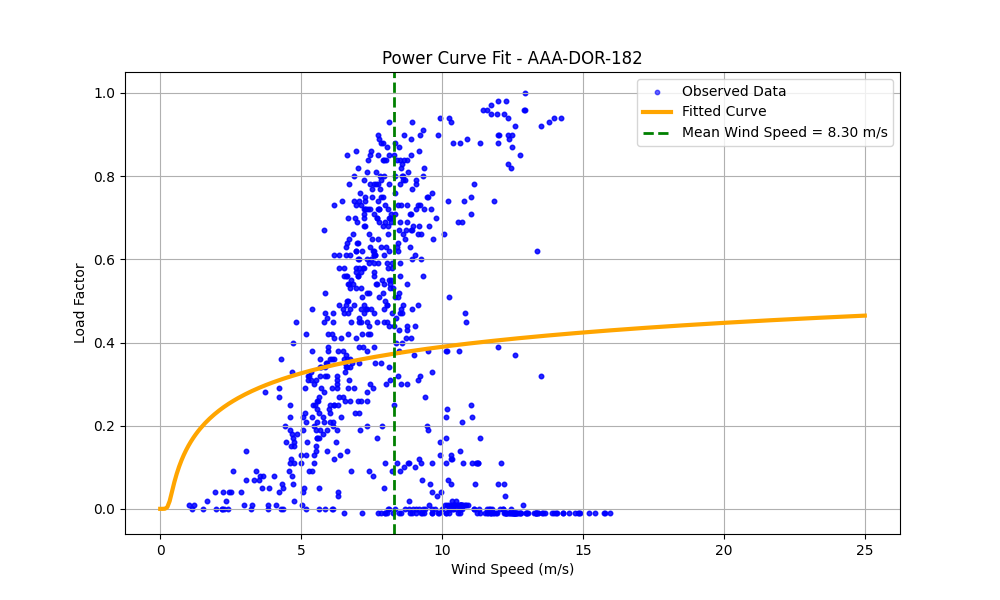

### PowerCurveFit_AAA-NAN-184.png

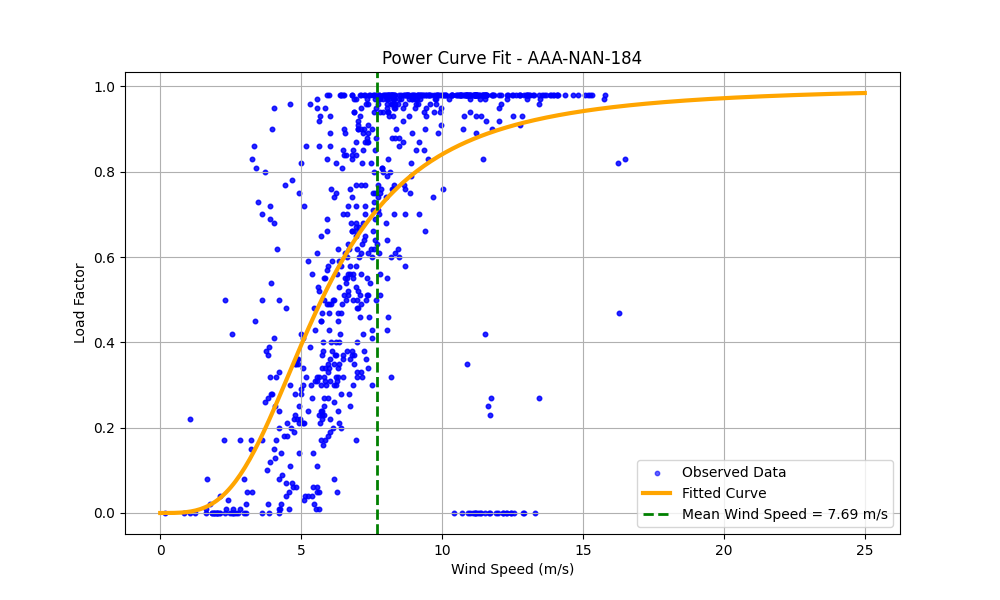

### PowerCurveFit_AAA-PNE-187.png

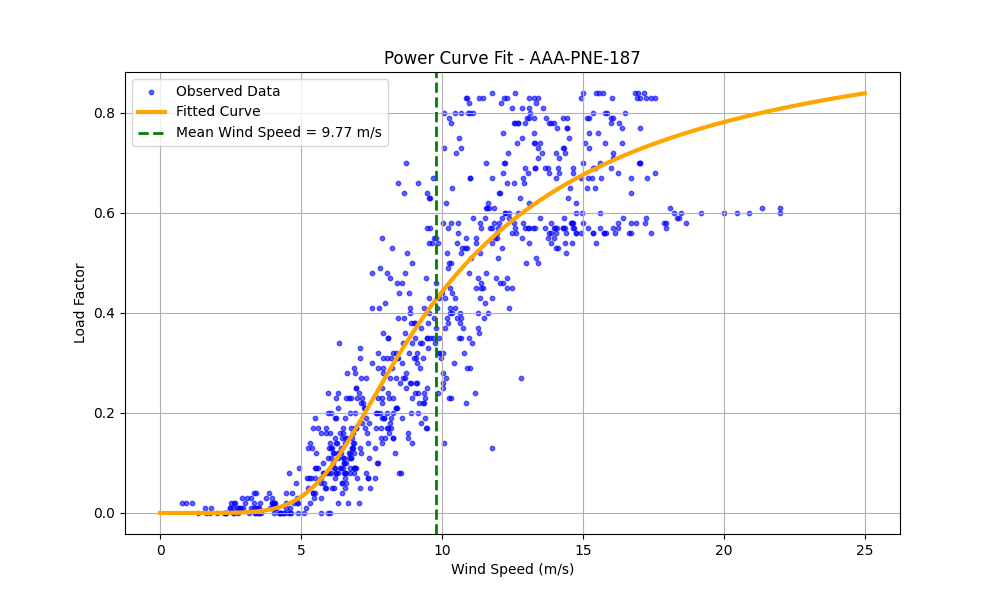

### PowerCurveFit_AAA-SOL-181.png

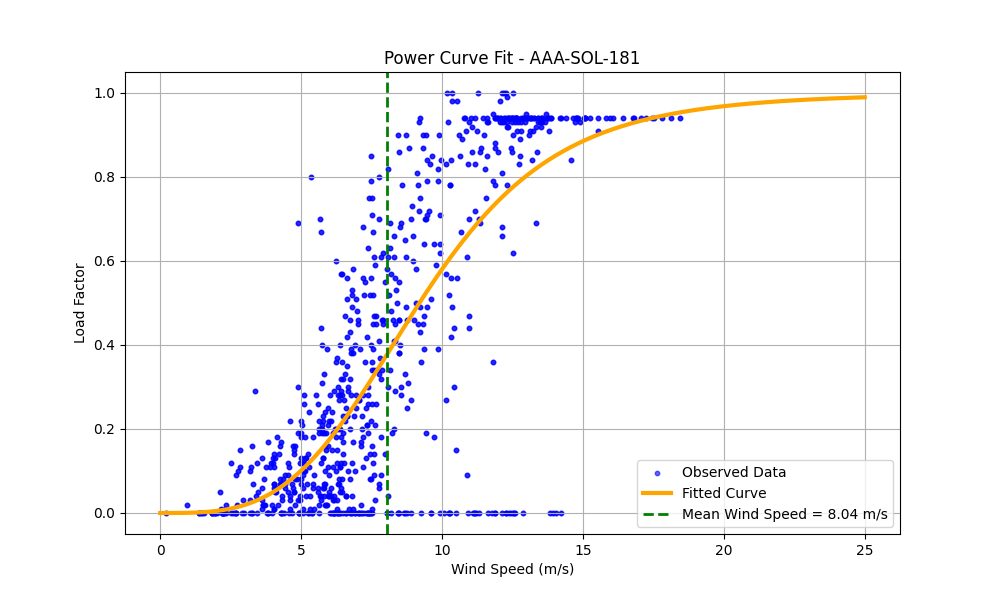

### PowerCurveFit_AR2-HRN-106.png

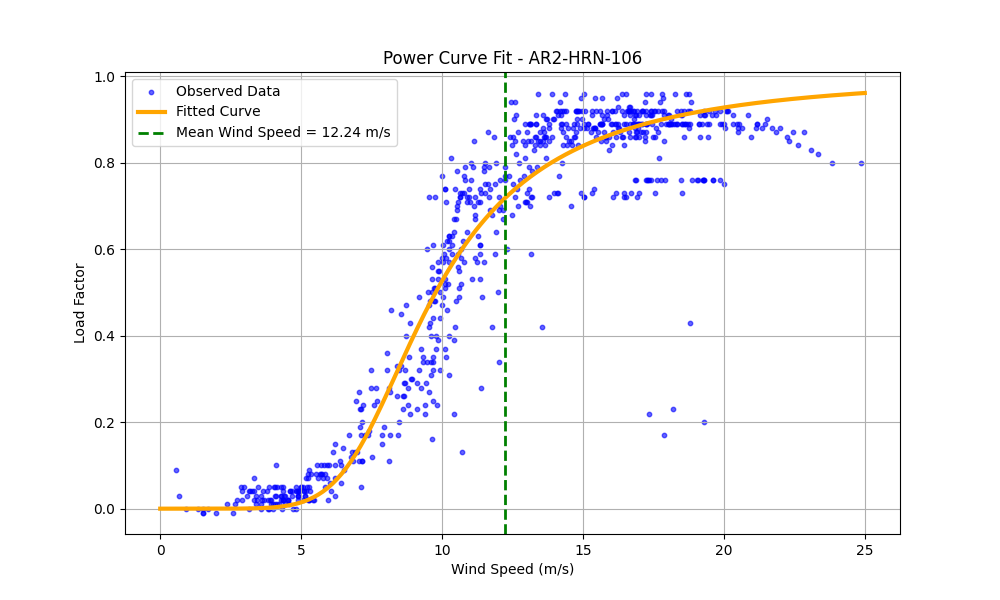

### PowerCurveFit_AR2-HRN-206.png

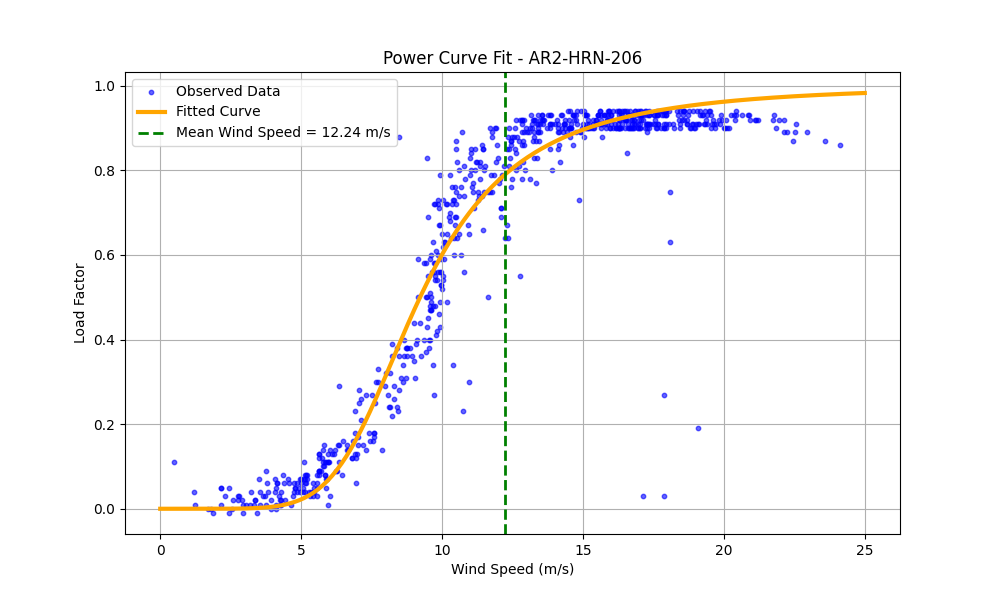

### PowerCurveFit_AR2-HRN-306.png

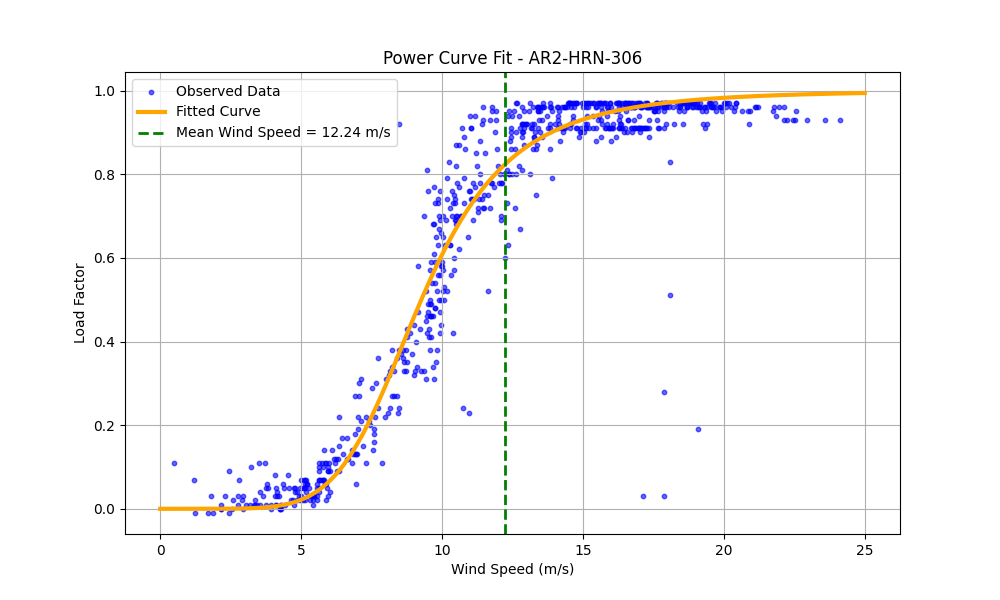

### PowerCurveFit_AR2-MRY-107.png

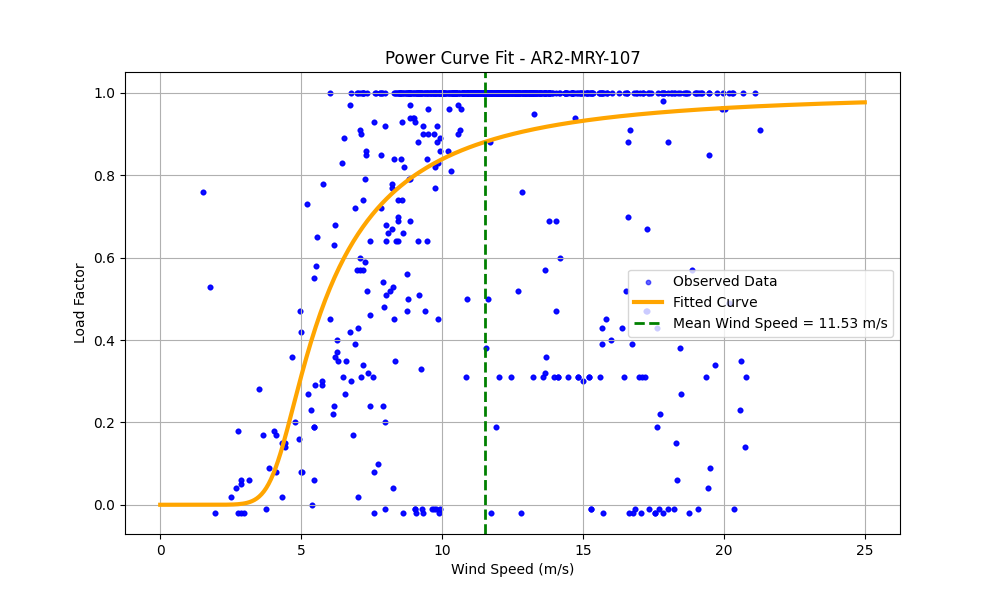

### PowerCurveFit_AR2-MRY-207.png

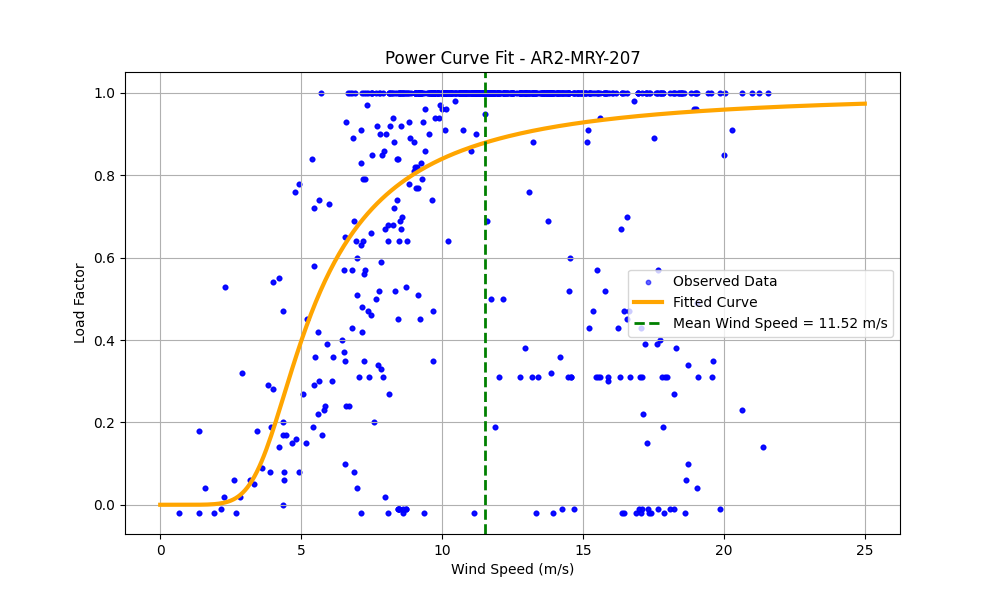

### PowerCurveFit_AR2-MRY-307.png

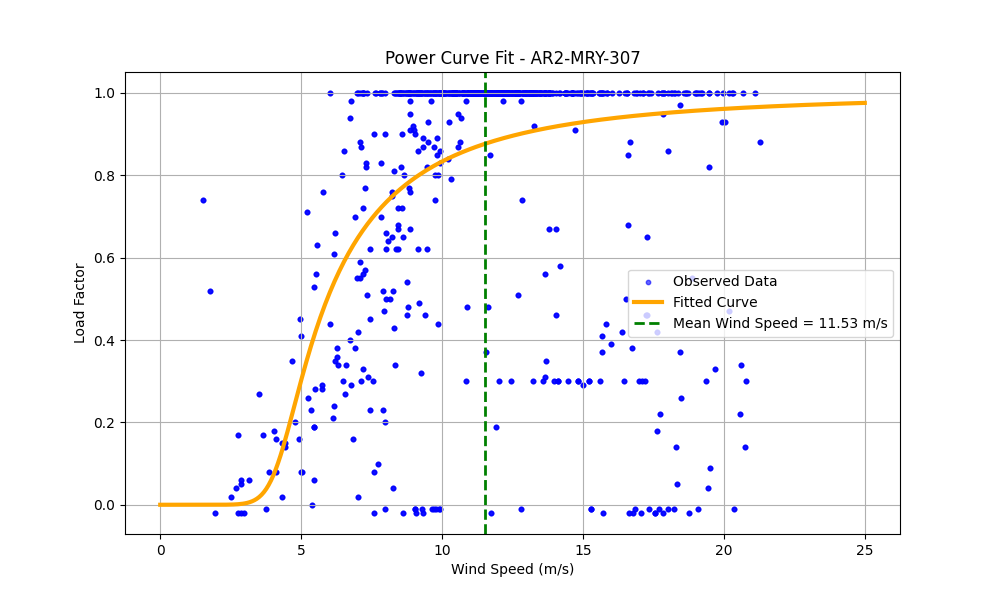

### PowerCurveFit_AR2-TKN-103.png

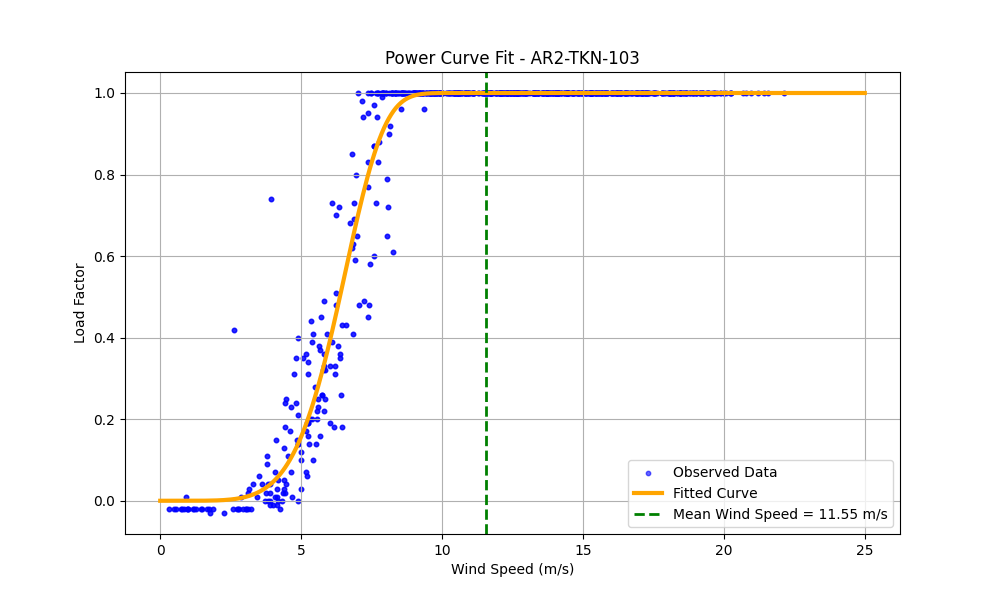

### PowerCurveFit_AR2-TKN-203.png

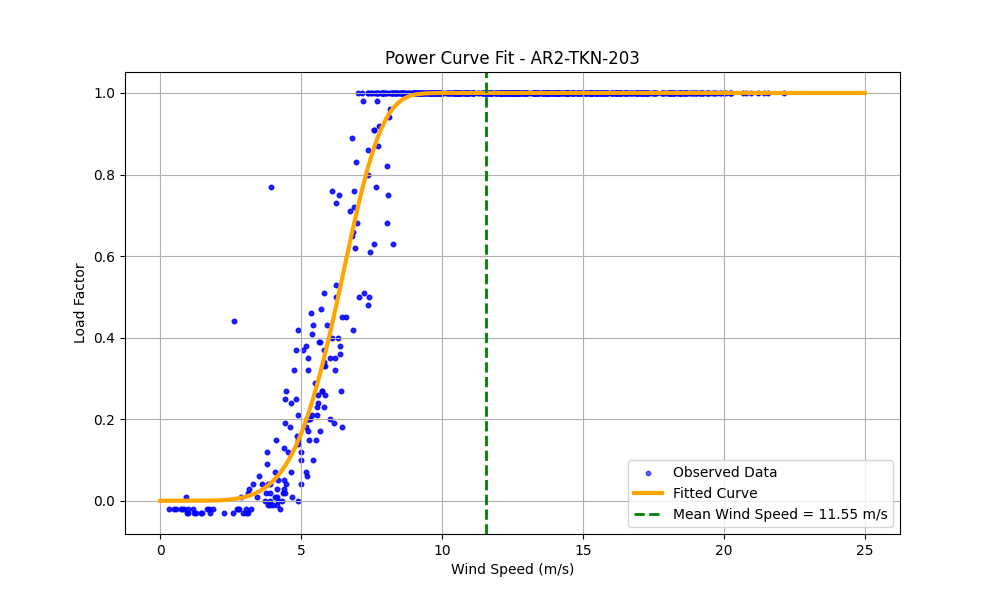

### PowerCurveFit_AR2-TKN-303.png

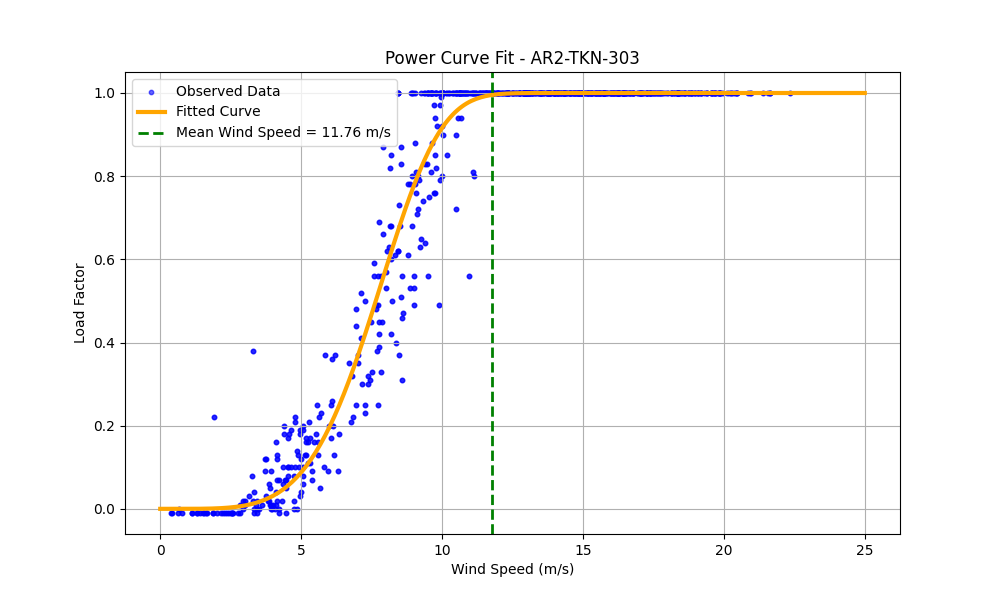

### PowerCurveFit_CAA-EAS-166.png

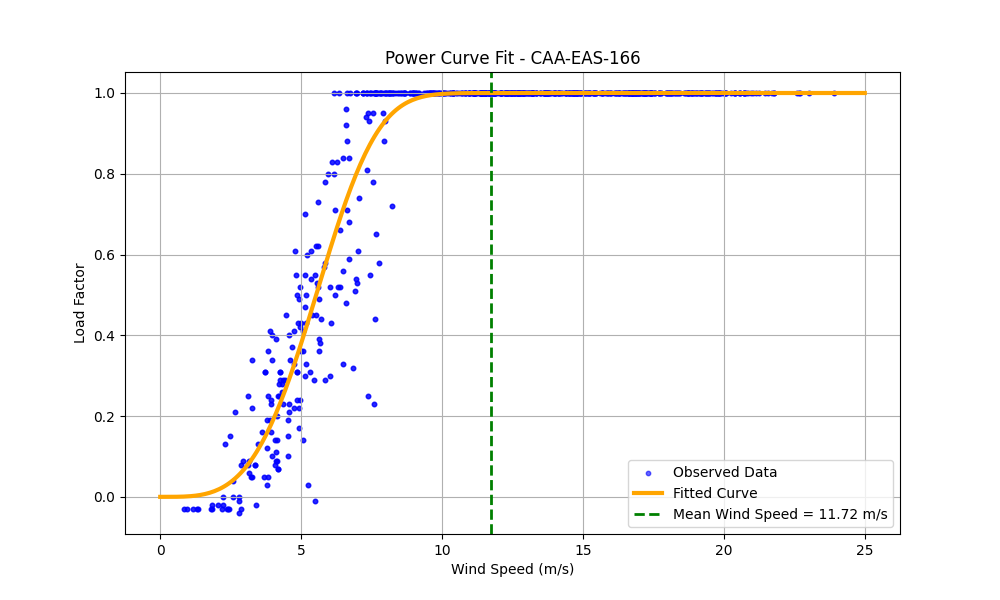

### PowerCurveFit_CAA-EAS-167.png

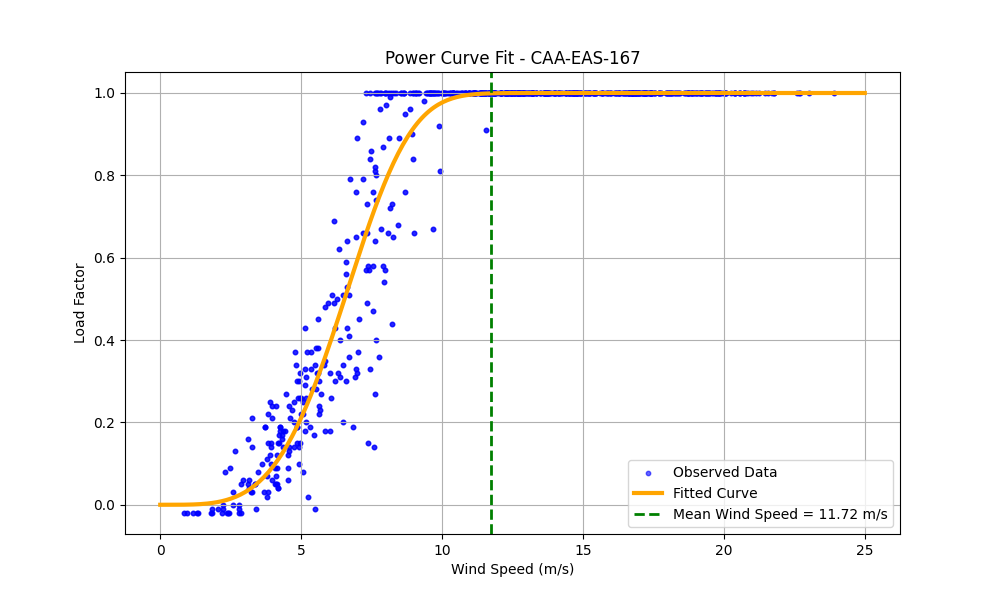

### PowerCurveFit_CAA-EAS-168.png

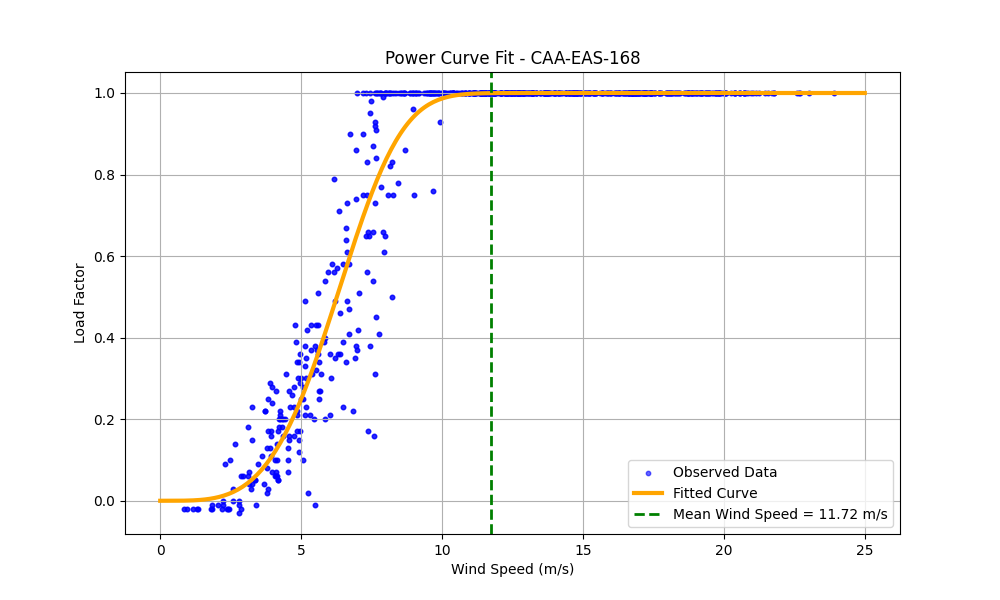

### PowerCurveFit_INV-BEA-001.png

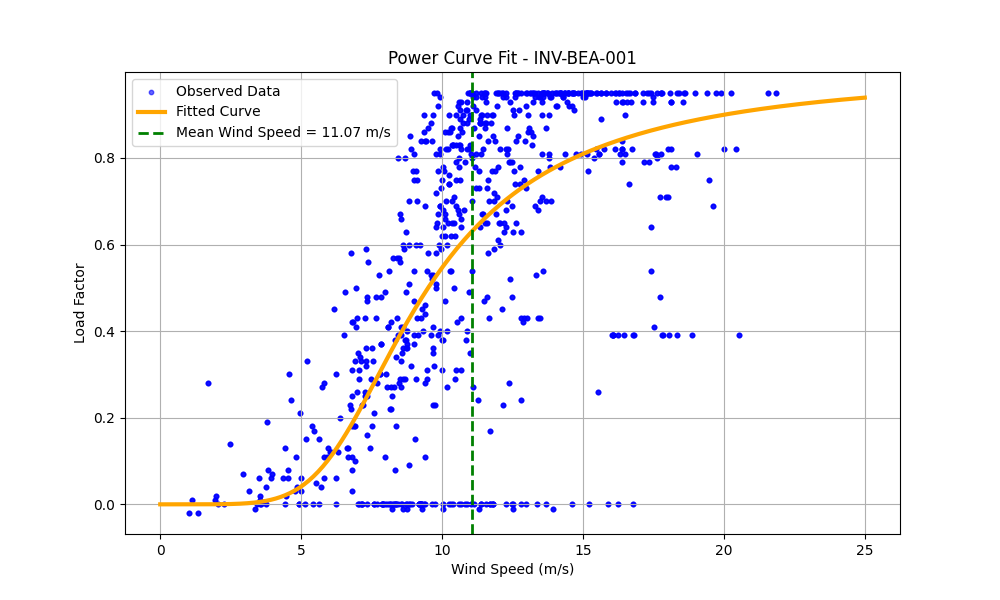

### PowerCurveFit_INV-BEA-002.png

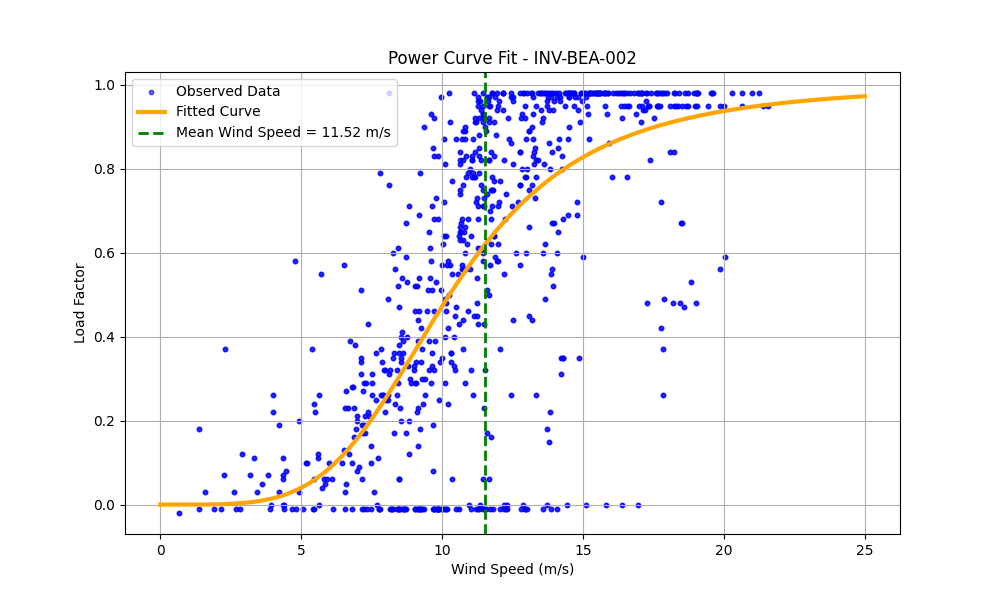

### PowerCurveFit_INV-BUR-001.png

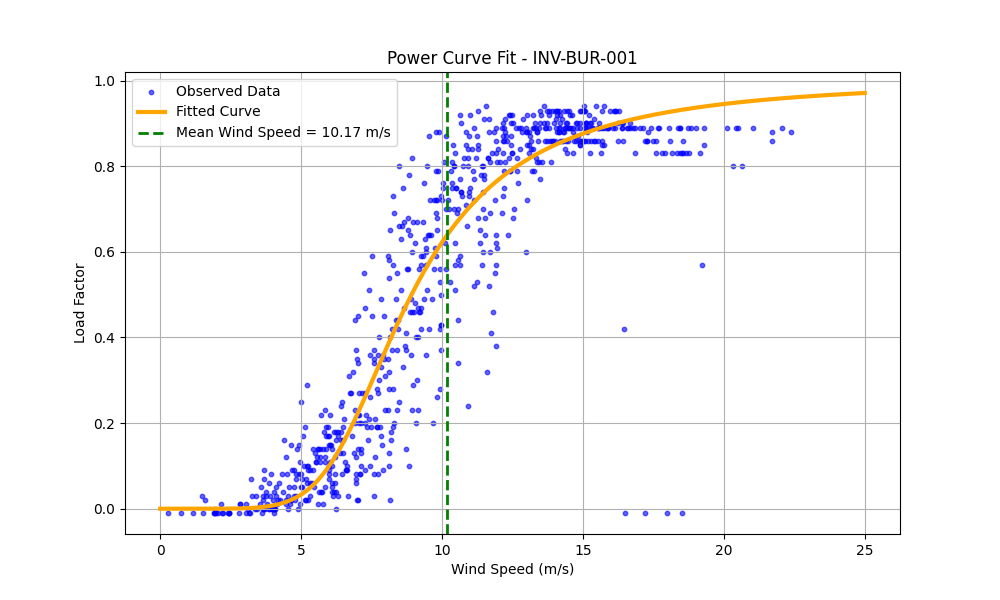

### PowerCurveFit_INV-DUD-001.png

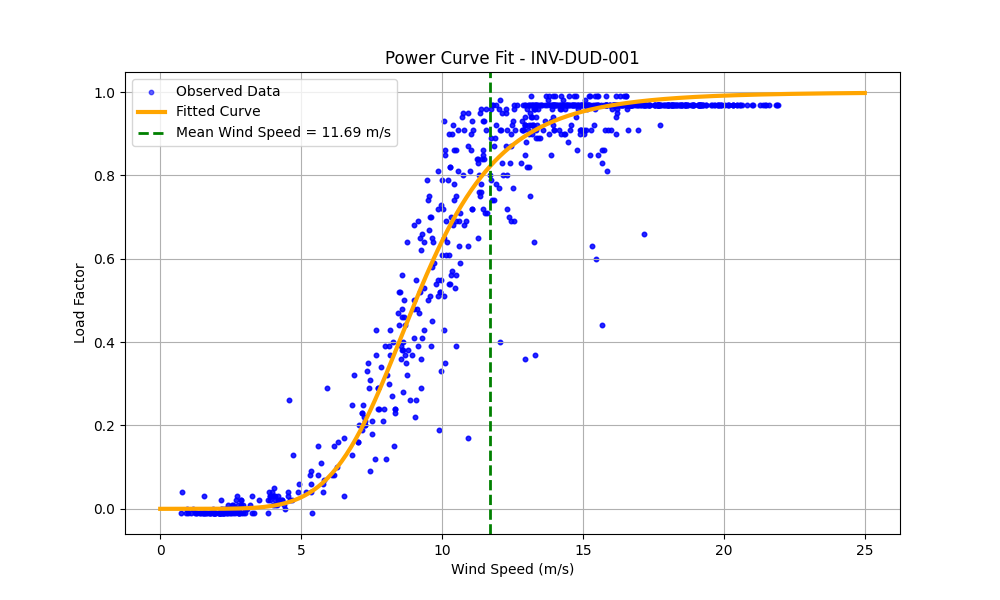

### PowerCurveFit_INV-DUD-002.png

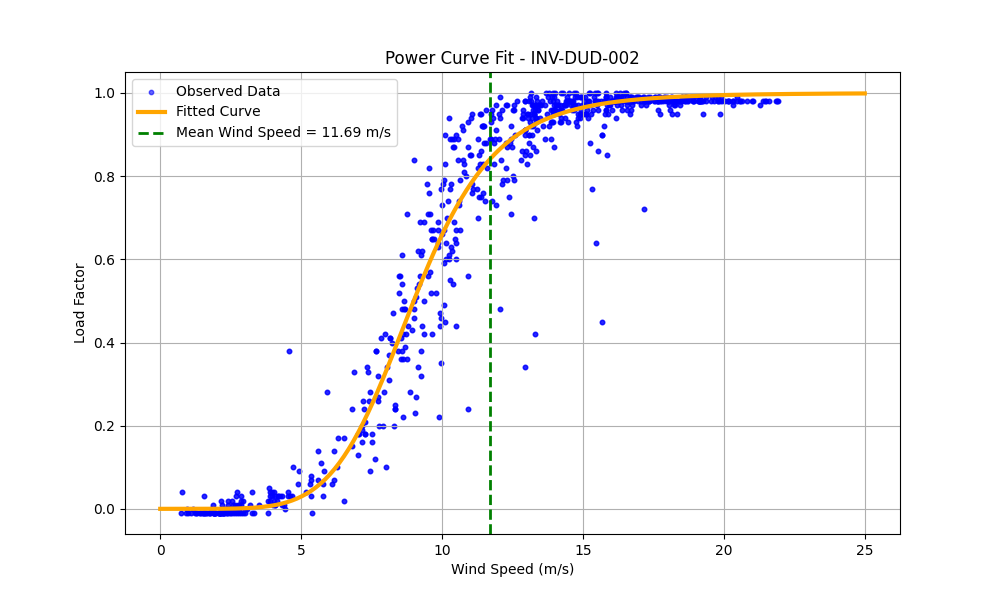

### PowerCurveFit_INV-DUD-003.png

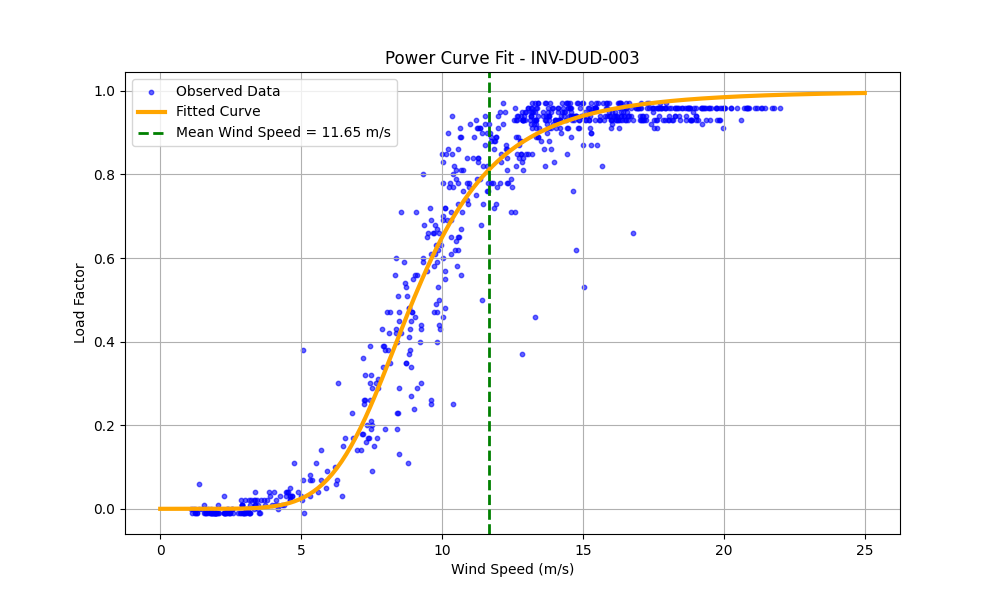

### PowerCurveFit_INV-HOR-001.png

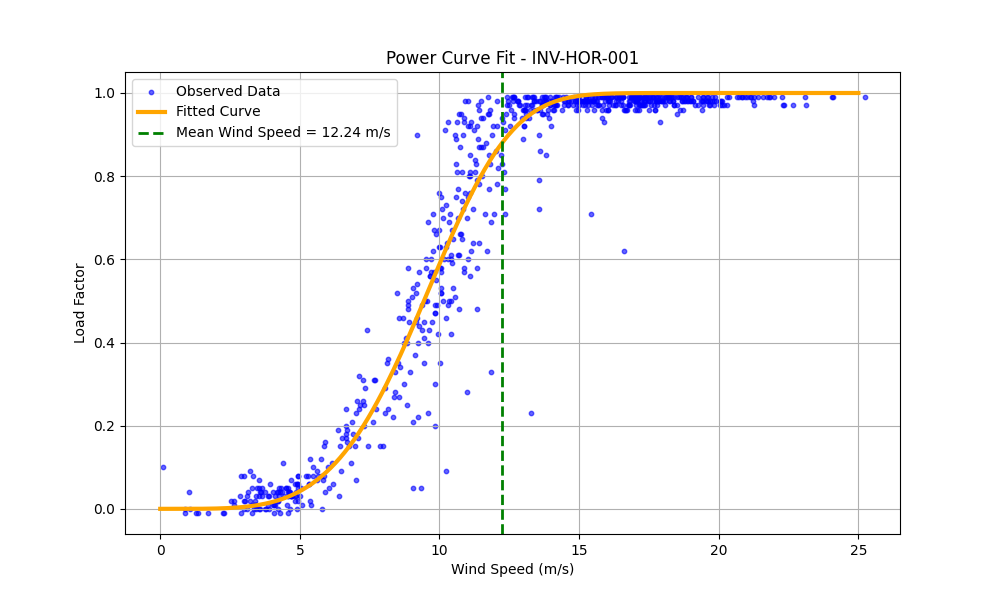

### PowerCurveFit_INV-HOR-002.png

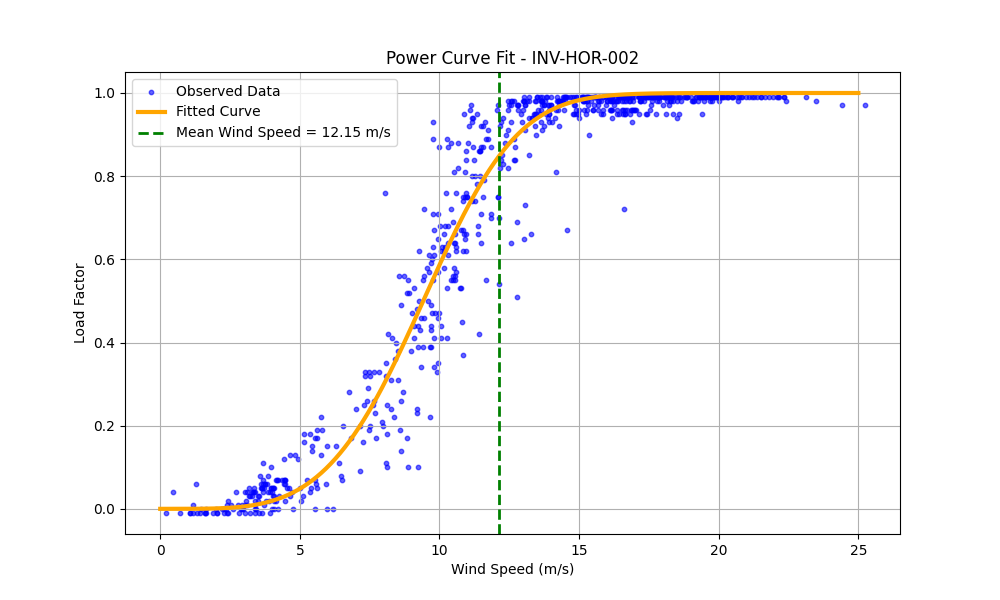

### PowerCurveFit_INV-HOR-003.png

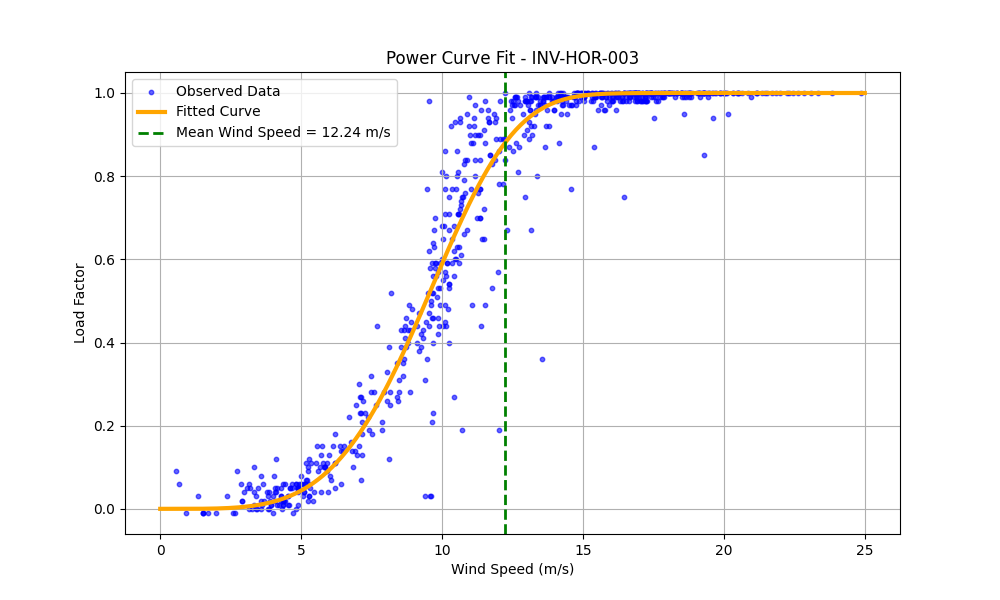

### PowerCurveFit_INV-WAL-001.png

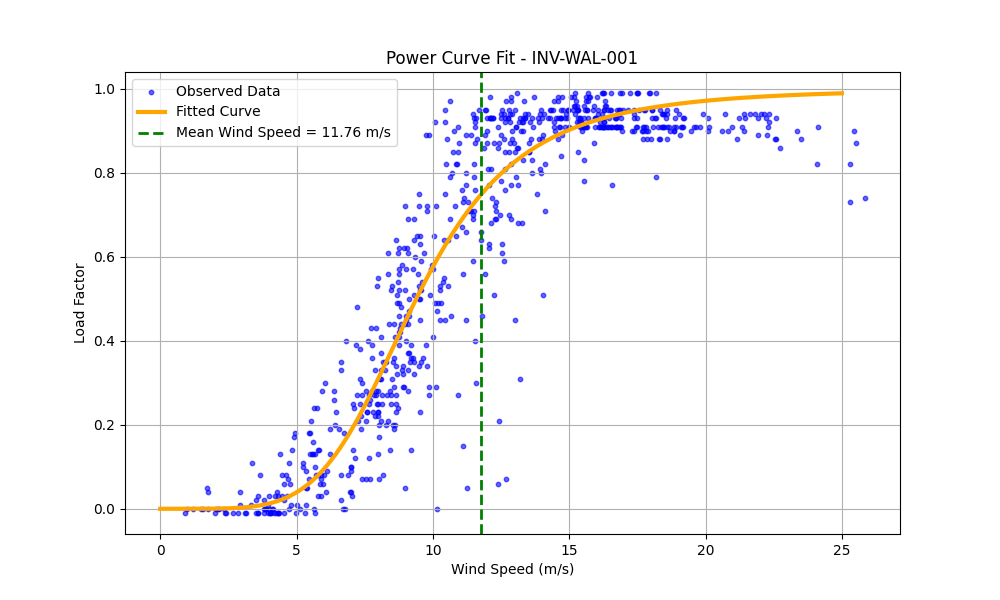

### PowerCurveFit_INV-WAL-002.png

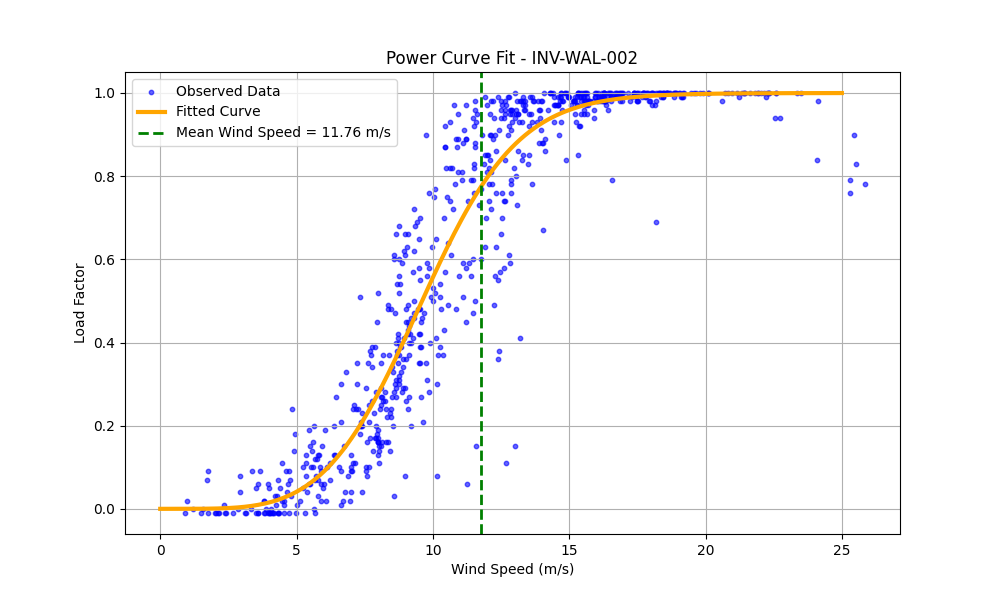

In [19]:
from pathlib import Path
from IPython.display import Image, display, Markdown

png_files = sorted(Path(OUTPUT_PATH).glob("PowerCurveFit_*.png"))

if not png_files:
    print("No PNG files found.")
else:
    print(f"Found {len(png_files)} PNG files.\n")
    for png in png_files:
        display(Markdown(f"### {png.name}"))
        display(Image(filename=str(png)))

## 7) Basic Troubleshooting

### ERA5 / NetCDF loading issues

If you see warnings like "Failed to load ... xarray IO backends ...":

1. Confirm dependencies are installed (including notebook extras):
   - `uv sync --group notebook`
2. Verify `netCDF4` is importable and print versions:
3. Try opening one ERA5 file with `engine='netcdf4'` (cell above).
4. Confirm `.nc` files are in `data/era5/` and not corrupted.

If no files load successfully, `WindCalibrator` raises: `ValueError: Failed to load any NetCDF files successfully`.

In [20]:
import importlib

for pkg in ['xarray', 'netCDF4', 'h5netcdf']:
    spec = importlib.util.find_spec(pkg)
    print(f'{pkg}:', 'installed' if spec else 'missing')

xarray: installed
netCDF4: missing
h5netcdf: missing


### Other quick checks

- Missing plant file: `data/plant/plant_data.csv`
- Missing generation file: `data/generation/generation_data.parquet`
- Missing ERA5 directory/files: `data/era5/*.nc`
- Permission issues writing output: ensure `output_path` is writable